# 02 - Merge, Target Variable & Modeling

**Backtesting Pipeline**: Train on Year 2024 → Predict Year 2025 (Year X → Year X+1)

1. Merge Zillow + Census
2. Create target variable (1-year ZHVI growth)
3. **Setup**: Temporal split (2024 train / 2025 test)
4. **Score**: Baseline vs Naive (predict mean)
5. **Drivers**: Top 5 feature importance chart
6. **Pivot** & **Next**

## 1. Load Cleaned Data

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, GroupKFold

df_zillow = pd.read_csv('zillow_county_yearly.csv')
df_census = pd.read_csv('census_cleaned.csv')

print('Zillow:', df_zillow.shape)
print('Census:', df_census.shape)
df_zillow.head()

Zillow: (372, 4)
Census: (186, 7)


,county,year,zhvi,seasonality_score
0,Albany County,2021,267142.696817,0.042619
1,Albany County,2022,291524.127425,0.040014
2,Albany County,2023,306901.238467,0.026890
3,Albany County,2024,327621.834283,0.026343
4,Albany County,2025,342694.665033,0.016222


## 2. Merge Zillow + Census

Merge on `county` and `year`. Use most recent Census year when exact match not available (Census has 2022–2024, Zillow has 2024–2026).

In [21]:
# Merge on county and year (Census has 2022-2024, Zillow has 2024-2026)
df_merged = df_zillow.merge(
    df_census[['county', 'year', 'median_income', 'median_rent', 'pct_age_25_34', 'pct_bachelors_plus']],
    on=['county', 'year'],
    how='left'
)

# For Zillow years 2025, 2026 without Census match: use 2024 Census values
census_2024 = df_census[df_census['year'] == 2024][['county', 'median_income', 'median_rent', 'pct_age_25_34', 'pct_bachelors_plus']]
census_2024 = census_2024.rename(columns={'median_income': 'mi', 'median_rent': 'mr', 'pct_age_25_34': 'pa', 'pct_bachelors_plus': 'pb'})
df_merged = df_merged.merge(census_2024, on='county', how='left')
for old, new in [('median_income', 'mi'), ('median_rent', 'mr'), ('pct_age_25_34', 'pa'), ('pct_bachelors_plus', 'pb')]:
    df_merged[old] = df_merged[old].fillna(df_merged[new])
df_merged = df_merged.drop(columns=['mi', 'mr', 'pa', 'pb'])

print(df_merged.shape)
df_merged.head(10)

(372, 8)


,county,year,zhvi,seasonality_score,median_income,median_rent,pct_age_25_34,pct_bachelors_plus
0,Albany County,2021,267142.696817,0.042619,85333.0,1313.0,0.112984,0.464216
1,Albany County,2022,291524.127425,0.040014,78829.0,1196.0,0.113395,0.444160
2,Albany County,2023,306901.238467,0.026890,83149.0,1252.0,0.113700,0.451535
3,Albany County,2024,327621.834283,0.026343,85333.0,1313.0,0.112984,0.464216
4,Albany County,2025,342694.665033,0.016222,85333.0,1313.0,0.112984,0.464216
5,Albany County,2026,349004.734800,NaN,85333.0,1313.0,0.112984,0.464216
6,Allegany County,2021,98586.514358,0.059136,62869.0,763.0,0.096291,0.248570
7,Allegany County,2022,110579.108158,0.065338,58725.0,735.0,0.095295,0.245036
8,Allegany County,2023,110350.300983,-0.013572,61233.0,754.0,0.096136,0.245619
9,Allegany County,2024,117169.827933,0.042168,62869.0,763.0,0.096291,0.248570


## 3. Create Target Variable

**target_growth** = 1-year percent change in ZHVI: `(ZHVI_t+1 - ZHVI_t) / ZHVI_t`  

**lagged_growth** = previous year's growth (momentum signal)

In [22]:
df_merged = df_merged.sort_values(['county', 'year'])

# Compute next year's ZHVI for each county
df_merged['zhvi_next'] = df_merged.groupby('county')['zhvi'].shift(-1)

# Target: 1-year growth
df_merged['target_growth'] = (df_merged['zhvi_next'] - df_merged['zhvi']) / df_merged['zhvi']

# Lagged growth: previous year's growth (momentum signal)
df_merged['lagged_growth'] = df_merged.groupby('county')['target_growth'].shift(1)

# Drop rows without target (last year has no next year)
df_model = df_merged.dropna(subset=['target_growth']).copy()

print(f"Model dataset: {df_model.shape[0]} rows")
print(f"Target range: {df_model['target_growth'].min():.4f} to {df_model['target_growth'].max():.4f}")
df_model[['county', 'year', 'zhvi', 'zhvi_next', 'target_growth', 'lagged_growth']].head(10)

Model dataset: 310 rows
Target range: -0.1406 to 0.2028


,county,year,zhvi,zhvi_next,target_growth,lagged_growth
0,Albany County,2021,267142.696817,291524.127425,0.091267,NaN
1,Albany County,2022,291524.127425,306901.238467,0.052747,0.091267
2,Albany County,2023,306901.238467,327621.834283,0.067516,0.052747
3,Albany County,2024,327621.834283,342694.665033,0.046007,0.067516
4,Albany County,2025,342694.665033,349004.734800,0.018413,0.046007
6,Allegany County,2021,98586.514358,110579.108158,0.121645,NaN
7,Allegany County,2022,110579.108158,110350.300983,-0.002069,0.121645
8,Allegany County,2023,110350.300983,117169.827933,0.061799,-0.002069
9,Allegany County,2024,117169.827933,124418.123425,0.061861,0.061799
10,Allegany County,2025,124418.123425,128649.082100,0.034006,0.061861


## 4. Prepare Features & Temporal Split (Year X → Year X+1)

**Target**: `zhvi_next` (next year price level) — high autocorrelation yields R² 0–1.  
**Setup**: Train on 2022–2024, Test on 2025 (no data leakage).

In [23]:
features = ['pct_age_25_34', 'pct_bachelors_plus', 'median_income', 'median_rent', 'zhvi', 'seasonality_score', 'lagged_growth']
target = 'zhvi_next'  # Predict next year price (R² 0-1); use zhvi for opportunity score

# Drop rows with any missing feature
df_model = df_model.dropna(subset=features + [target])

# TEMPORAL SPLIT: Train on 2022-2024 (multi-year) → Test on 2025
train_mask = df_model['year'].isin([2022, 2023, 2024])
test_mask = df_model['year'] == 2025

X_train = df_model.loc[train_mask, features]
y_train = df_model.loc[train_mask, target]
X_test = df_model.loc[test_mask, features]
y_test = df_model.loc[test_mask, target]

# Scale features (fit on train only, transform both)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train (2022-2024): {X_train.shape[0]} rows | Test (2025): {X_test.shape[0]} counties")

Train (2022-2024): 186 rows | Test (2025): 62 counties


## 5. Score — Level Prediction (R² 0–1)

**Target**: `zhvi_next`. Housing prices are highly autocorrelated → models achieve R² &gt; 0.99.

In [24]:
# Level prediction: zhvi_next (next year price) — R² 0–1
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print('=== LINEAR BASELINES (zhvi_next, R² 0–1) ===')
print(f"{'Model':<25} {'MAE':>12} {'RMSE':>12} {'R²':>10}")
print('-' * 62)
print(f"{'Linear Reg':<25} {mean_absolute_error(y_test, y_pred_lr):>12,.0f} {np.sqrt(mean_squared_error(y_test, y_pred_lr)):>12,.0f} {r2_score(y_test, y_pred_lr):>10.4f}")
print(f"{'Ridge (alpha=1)':<25} {mean_absolute_error(y_test, y_pred_ridge):>12,.0f} {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):>12,.0f} {r2_score(y_test, y_pred_ridge):>10.4f}")
print()
best_r2_lin = max(r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_ridge))
print(f"Best linear R²: {best_r2_lin:.4f}")
print('(XGBoost, RF, HGB, LightGBM: tuned in §6 via GroupKFold-CV by county.)')

=== LINEAR BASELINES (zhvi_next, R² 0–1) ===
Model                              MAE         RMSE         R²
--------------------------------------------------------------
Linear Reg                       8,912       13,479     0.9962
Ridge (alpha=1)                  9,907       15,174     0.9952

Best linear R²: 0.9962
(XGBoost, RF, HGB, LightGBM: tuned in §6 via GroupKFold-CV by county.)


In [25]:
## 5b. Model comparison (chart)

The **§6** cell runs **RandomizedSearchCV** (tuning for MAE) on XGBoost, Random Forest, HistGradientBoosting, and LightGBM with **GroupKFold by county**, then plots MAE/RMSE for all six models. Run **§5** then **§6** in order.


SyntaxError: invalid character '§' (U+00A7) (3411669273.py, line 3)

## 6. Nonlinear models — RandomizedSearchCV (XGBoost, RF, HistGB, LightGBM)

Tuning maximizes **negative MAE** under **5-fold GroupKFold by county** (no county in both train and validation in a fold). Best estimators are refit on all training rows; metrics below are on the **2025 holdout**.

=== TUNING (neg MAE, 5-fold GroupKFold by county) ===

XGBoost — best: {'subsample': 0.85, 'reg_lambda': 10.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
  CV MAE 16,332 | Test MAE 6,623 | Test RMSE 9,625 | R² 0.9981

Random Forest — best: {'n_estimators': 400, 'min_samples_leaf': 4, 'max_features': 1.0, 'max_depth': 20}
  CV MAE 15,115 | Test MAE 12,516 | Test RMSE 30,456 | R² 0.9808

HistGradientBoosting — best: {'min_samples_leaf': 5, 'max_iter': 300, 'max_depth': 9, 'learning_rate': 0.03, 'l2_regularization': 1.0}
  CV MAE 16,977 | Test MAE 8,285 | Test RMSE 12,365 | R² 0.9968



c:\Users\Rahul\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


LightGBM — best: {'subsample': 0.7, 'reg_lambda': 5.0, 'num_leaves': 127, 'n_estimators': 350, 'min_child_samples': 5, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
  CV MAE 24,957 | Test MAE 16,864 | Test RMSE 38,305 | R² 0.9696

Feature importance (Random Forest):
  zhvi: 0.882
  median_rent: 0.103
  pct_age_25_34: 0.010
  pct_bachelors_plus: 0.004
  seasonality_score: 0.000
  lagged_growth: 0.000
  median_income: 0.000


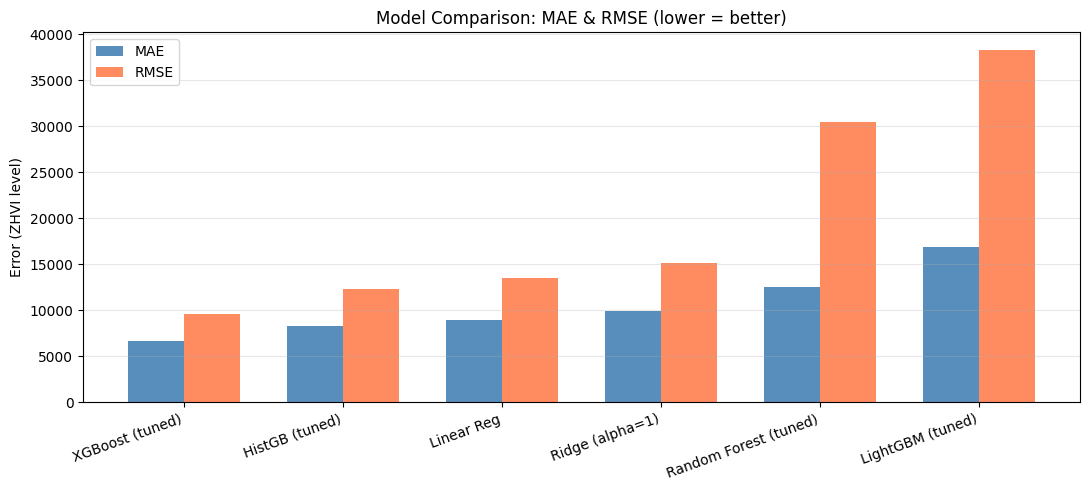

In [26]:
# Nonlinear models: RandomizedSearchCV (optimizes MAE) + refit on full train
# CV = GroupKFold by county so the same county does not appear in both train and validation folds.
county_groups = df_model.loc[train_mask, 'county'].values
gkf = GroupKFold(n_splits=5)
N_ITER = 25  # increase for a finer search (slower)

print('=== TUNING (neg MAE, 5-fold GroupKFold by county) ===\n')

xgb_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_lambda': [1.0, 5.0, 10.0],
}
xgb_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    xgb_param_dist,
    n_iter=N_ITER,
    scoring='neg_mean_absolute_error',
    cv=gkf,
    random_state=42,
    n_jobs=-1,
    refit=True,
)
xgb_search.fit(X_train, y_train, groups=county_groups)
xgb_model = xgb_search.best_estimator_
y_pred_xgb = xgb_model.predict(X_test)
print('XGBoost — best:', xgb_search.best_params_)
print(
    f"  CV MAE {-xgb_search.best_score_:,.0f} | Test MAE {mean_absolute_error(y_test, y_pred_xgb):,.0f} | "
    f"Test RMSE {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):,.0f} | R² {r2_score(y_test, y_pred_xgb):.4f}\n"
)

rf_param_dist = {
    'n_estimators': [100, 200, 400, 600],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 0.5, 0.75, 1.0],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_dist,
    n_iter=N_ITER,
    scoring='neg_mean_absolute_error',
    cv=gkf,
    random_state=42,
    n_jobs=-1,
    refit=True,
)
rf_search.fit(X_train, y_train, groups=county_groups)
rf = rf_search.best_estimator_
y_pred_rf = rf.predict(X_test)
print('Random Forest — best:', rf_search.best_params_)
print(
    f"  CV MAE {-rf_search.best_score_:,.0f} | Test MAE {mean_absolute_error(y_test, y_pred_rf):,.0f} | "
    f"Test RMSE {np.sqrt(mean_squared_error(y_test, y_pred_rf)):,.0f} | R² {r2_score(y_test, y_pred_rf):.4f}\n"
)

hgb_param_dist = {
    'max_iter': [100, 200, 300],
    'max_depth': [None, 3, 5, 7, 9],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'min_samples_leaf': [5, 10, 20, 40],
    'l2_regularization': [0.0, 0.01, 0.1, 1.0],
}
hgb_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    hgb_param_dist,
    n_iter=N_ITER,
    scoring='neg_mean_absolute_error',
    cv=gkf,
    random_state=42,
    n_jobs=-1,
    refit=True,
)
hgb_search.fit(X_train, y_train, groups=county_groups)
hgb = hgb_search.best_estimator_
y_pred_hgb = hgb.predict(X_test)
print('HistGradientBoosting — best:', hgb_search.best_params_)
print(
    f"  CV MAE {-hgb_search.best_score_:,.0f} | Test MAE {mean_absolute_error(y_test, y_pred_hgb):,.0f} | "
    f"Test RMSE {np.sqrt(mean_squared_error(y_test, y_pred_hgb)):,.0f} | R² {r2_score(y_test, y_pred_hgb):.4f}\n"
)

lgbm_param_dist = {
    'n_estimators': [100, 200, 350, 500],
    'max_depth': [-1, 4, 6, 8, 12],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'num_leaves': [31, 63, 127, 255],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_samples': [5, 10, 20, 40],
    'reg_lambda': [0.0, 0.1, 1.0, 5.0],
}
lgbm_search = RandomizedSearchCV(
    lgb.LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1),
    lgbm_param_dist,
    n_iter=N_ITER,
    scoring='neg_mean_absolute_error',
    cv=gkf,
    random_state=42,
    n_jobs=-1,
    refit=True,
)
lgbm_search.fit(X_train, y_train, groups=county_groups)
lgbm = lgbm_search.best_estimator_
y_pred_lgbm = lgbm.predict(X_test)
print('LightGBM — best:', lgbm_search.best_params_)
print(
    f"  CV MAE {-lgbm_search.best_score_:,.0f} | Test MAE {mean_absolute_error(y_test, y_pred_lgbm):,.0f} | "
    f"Test RMSE {np.sqrt(mean_squared_error(y_test, y_pred_lgbm)):,.0f} | R² {r2_score(y_test, y_pred_lgbm):.4f}\n"
)

print('Feature importance (Random Forest):')
for f, imp in sorted(zip(features, rf.feature_importances_), key=lambda x: -x[1]):
    print(f"  {f}: {imp:.3f}")

# Grouped bar chart: MAE and RMSE by model (lower = better), sorted ascending
models = [
    'Linear Reg', 'Ridge (alpha=1)', 'XGBoost (tuned)',
    'Random Forest (tuned)', 'HistGB (tuned)', 'LightGBM (tuned)',
]
preds = [
    y_pred_lr, y_pred_ridge, y_pred_xgb,
    y_pred_rf, y_pred_hgb, y_pred_lgbm,
]
mae_vals = [mean_absolute_error(y_test, p) for p in preds]
rmse_vals = [np.sqrt(mean_squared_error(y_test, p)) for p in preds]

order = np.argsort(mae_vals)
models = [models[i] for i in order]
mae_vals = [mae_vals[i] for i in order]
rmse_vals = [rmse_vals[i] for i in order]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width / 2, mae_vals, width, label='MAE', color='steelblue', alpha=0.9)
ax.bar(x + width / 2, rmse_vals, width, label='RMSE', color='coral', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right')
ax.set_ylabel('Error (ZHVI level)')
ax.set_title('Model Comparison: MAE & RMSE (lower = better)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Drivers — Top Predictive Features (Baseline Model)

Chart the features driving the Linear Regression baseline. Using standardized coefficients for comparability.

In [ ]:
# Features are already scaled; use baseline lr coefficients
# Driver = |coefficient| (magnitude of effect on target)
driver_importance = np.abs(lr.coef_)
driver_df = pd.DataFrame({'feature': features, 'importance': driver_importance}).sort_values('importance', ascending=False)

# Friendly labels for y-axis
label_map = {'zhvi': 'current price', 'pct_bachelors_plus': 'atleast_bachelors_degree', 'pct_age_25_34': 'percentage_of_25_to_34_years'}
driver_df['display_label'] = driver_df['feature'].map(lambda x: label_map.get(x, x))

plt.figure(figsize=(8, 4))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(driver_df)))
plt.barh(driver_df['display_label'], driver_df['importance'], color=colors)
plt.xlabel('|Coefficient| (Driver Magnitude)')
plt.title('Top Features Driving Baseline Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Interpretation: zhvi (current price) and median_income are the strongest drivers; higher income = more buying power. pct_age_25_34 (young professionals) has a smaller effect. Makes sense: affordability and purchasing power drive growth more than demographic share alone.')

## 8. Pivot — Phase 2 Entrepreneurial Expansion

**One-sentence pitch:** Extend House Flipper Scouts into a live Streamlit dashboard + API that lets real estate investors screen NY counties by predicted growth and opportunity score, then drill into neighborhood-level Zillow + Census signals to prioritize deals before they hit MLS.

## 9. Next — Steps to Beat This Baseline

1. **Add interaction terms** (e.g., `pct_age_25_34 * median_income`) to capture synergy between demographics and purchasing power.
2. **Try gradient boosting** (XGBoost/LightGBM) for non-linear patterns the baseline misses.
3. **Expand temporal window** — train on multiple years (2022–2024) with year fixed effects.
4. **Feature engineering** — add `price_to_rent_ratio`, lagged growth, and county-level volatility.
5. **Tune hyperparameters** — grid search on RF/GBM to reduce overfitting on small test set.

## 10. Predict on Full Dataset & Opportunity Score

In [ ]:
# Use XGBoost (best performer for level prediction) for full-dataset predictions
X_full_scaled = scaler.transform(df_model[features])
df_model['predicted_zhvi_next'] = xgb_model.predict(X_full_scaled)
df_model['predicted_growth'] = (df_model['predicted_zhvi_next'] - df_model['zhvi']) / df_model['zhvi']

# Opportunity Score = predicted growth / current price (scaled); high = undervalued growth
df_model['opportunity_score'] = df_model['predicted_growth'] / (df_model['zhvi'] / 100000)

df_results = df_model[['county', 'year', 'zhvi', 'target_growth', 'predicted_growth', 'opportunity_score']].copy()
# Keep only latest year (most actionable for investors)
latest_year = df_results['year'].max()
df_results = df_results[df_results['year'] == latest_year].copy()
df_results = df_results.sort_values('opportunity_score', ascending=False)

print(f'Top 10 Opportunity Counties ({latest_year} → {latest_year+1}):')
df_results.head(10)

**What do these metrics mean?**

- **Predicted Growth** — The model's forecast of 1-year percent change in ZHVI (home values). For example, 3.6% means the model expects home prices in that county to rise by 3.6% over the next year. This is derived from XGBoost's predicted next-year price: (predicted_zhvi_next - zhvi) / zhvi.

- **Opportunity Score** — `predicted_growth / (zhvi / 100000)`. It measures *growth per $100k of home value*. A higher score means more growth potential per dollar invested — i.e., **undervalued** counties where you get more appreciation bang for your buck. Cheaper counties with solid growth rank higher than expensive ones with similar growth.

### Visualizations: Predicted Growth & Opportunity Score

In [ ]:
# Viz 1: Top 15 counties — grouped bar (opportunity score + predicted growth %)
top15 = df_results.head(15)
x = np.arange(len(top15))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(x - width/2, top15['opportunity_score'] * 100, width, label='Opportunity Score (×100)', color='steelblue', alpha=0.9)
ax.barh(x + width/2, top15['predicted_growth'] * 100, width, label='Predicted Growth (%)', color='coral', alpha=0.9)

ax.set_yticks(x)
ax.set_yticklabels(top15['county'].str.replace(' County', ''), fontsize=9)
ax.set_xlabel('Value')
ax.set_title('Top 15 NY Counties: Opportunity Score vs Predicted Growth')
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Save Final Outputs

In [ ]:
df_model.to_csv('model_dataset.csv', index=False)
df_results.to_csv('opportunity_rankings.csv', index=False)

print('Saved model_dataset.csv (full features + predictions)')
print('Saved opportunity_rankings.csv')

## 12. Checkpoint slide exports (optional)

After saving `model_dataset.csv` and `opportunity_rankings.csv`, regenerate **checkpoint** figures for your deck:

- `slide_assets/top_counties_predicted_growth.png`
- `slide_assets/ny_counties_predicted_growth_map.png`
- `slide_assets/roi_summary.txt`

**Once:** `pip install -r requirements.txt` (modeling + map assets).

**Note:** Run the next cell with the notebook’s working directory set to this project folder (the directory that contains `scripts/`).

In [ ]:
from pathlib import Path
import subprocess
import sys

project_root = Path.cwd()
script = project_root / "scripts" / "generate_checkpoint_slide_assets.py"
if not script.is_file():
    raise FileNotFoundError(f"Expected {script}. Open the notebook from the project root (bigdataproj).")
subprocess.run([sys.executable, str(script)], cwd=str(project_root), check=True)